# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# Load Dataset

In [2]:
# Load dataset from Downloads folder
df= pd.read_csv(r"C:\Users\PMLS\Downloads\MB_dataset.csv")
# View first few rows
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-02,41.092484,41.845215,40.971882,41.566578,33.846729,2973654
1,2020-01-03,41.296261,41.362801,40.302322,40.813847,33.233799,4014262
2,2020-01-06,40.202515,40.593433,39.703465,40.593433,33.054317,3441396
3,2020-01-07,40.797215,41.208927,40.680767,40.917816,33.318455,2816618
4,2020-01-08,40.589275,41.167339,40.489468,41.146545,33.504704,2659070


# Exploratory Data Analysis

In [3]:
print(df.shape)

print (df.info())

print (df.describe())

(1105, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1105 non-null   object 
 1   Open       1105 non-null   float64
 2   High       1105 non-null   float64
 3   Low        1105 non-null   float64
 4   Close      1105 non-null   float64
 5   Adj Close  1105 non-null   float64
 6   Volume     1105 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 60.6+ KB
None
              Open         High          Low        Close    Adj Close  \
count  1105.000000  1105.000000  1105.000000  1105.000000  1105.000000   
mean     57.601284    58.280954    56.878953    57.592108    52.302903   
std      14.356715    14.382103    14.309748    14.356889    15.105935   
min      18.061396    19.225842    17.479174    18.165363    14.791645   
25%      50.395580    52.060001    49.988022    50.619999    45.035072   
50%      62.

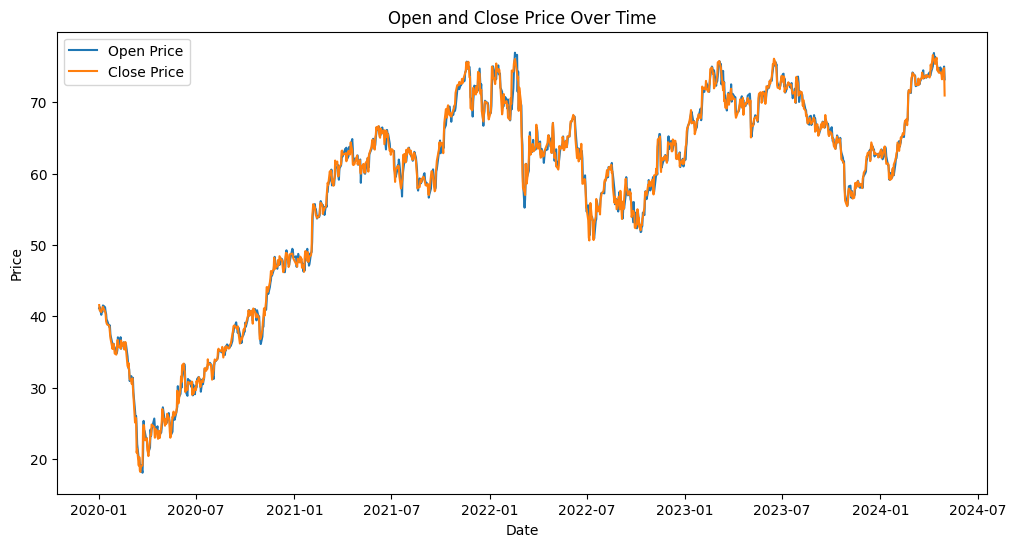

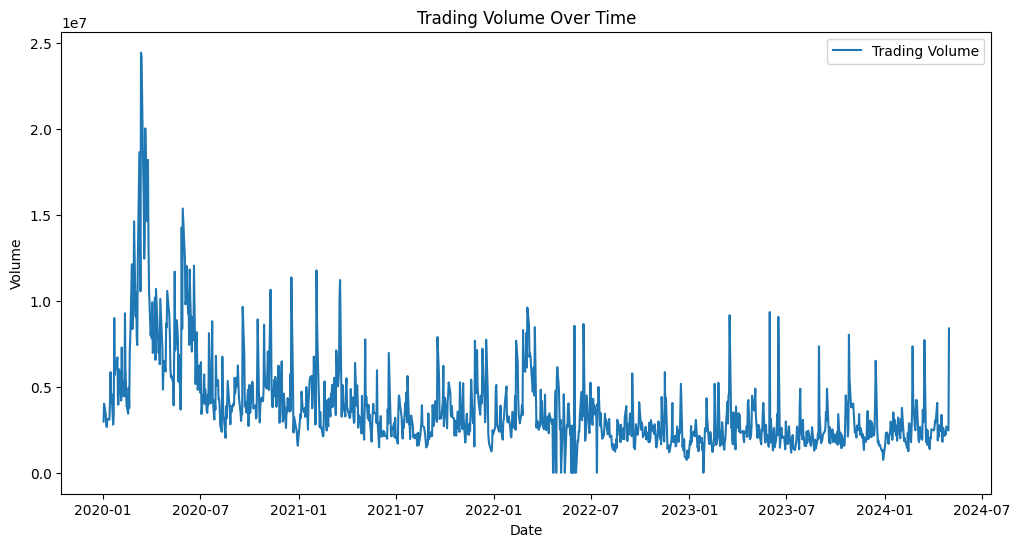

In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# --------------------
# Plot Open and Close Prices
# --------------------
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label='Open Price')
plt.plot(df['Close'], label='Close Price')
plt.title("Open and Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# --------------------
# Plot Trading Volume
# --------------------
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label='Trading Volume')
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.show()

In [5]:

df= df.drop('Close' , axis=1)

print (df.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1105 entries, 2020-01-02 to 2024-04-30
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1105 non-null   float64
 1   High       1105 non-null   float64
 2   Low        1105 non-null   float64
 3   Adj Close  1105 non-null   float64
 4   Volume     1105 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 51.8 KB
None


In [6]:
# -------------------------------
# Feature Engineering for Stock Data
# -------------------------------

# Moving averages (MA)
# MA smooths the price over a fixed number of days to capture the trend.
# MA5  -> 5-day moving average
# MA10 -> 10-day moving average
# MA20 -> 20-day moving average
df['MA5'] = df['Adj Close'].rolling(window=5).mean()
df['MA10'] = df['Adj Close'].rolling(window=10).mean()
df['MA20'] = df['Adj Close'].rolling(window=20).mean()

# Daily returns
# Daily return measures the percentage change in price from the previous day.
# It captures momentum or direction of price movement.
df['Return'] = df['Adj Close'].pct_change()

# Price range (volatility)
# Difference between High and Low of the day.
# Indicates how much the price fluctuated during the day (volatility measure).
df['Range'] = df['High'] - df['Low']

# Lagged features (previous day or previous 5 days Adj Close)
# Lag1 captures the previous day's closing price.
# Lag5 captures the closing price 5 days ago.
# Useful for models to learn historical dependencies.
df['Adj_Close_Lag1'] = df['Adj Close'].shift(1)
df['Adj_Close_Lag5'] = df['Adj Close'].shift(5)

# Drop NaN values generated by rolling/shift operations
# Rolling averages and lagged features produce NaN values for initial rows.
# Removing them ensures a clean dataset for training.
df.dropna(inplace=True)

print (df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1086 entries, 2020-01-29 to 2024-04-30
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Open            1086 non-null   float64
 1   High            1086 non-null   float64
 2   Low             1086 non-null   float64
 3   Adj Close       1086 non-null   float64
 4   Volume          1086 non-null   int64  
 5   MA5             1086 non-null   float64
 6   MA10            1086 non-null   float64
 7   MA20            1086 non-null   float64
 8   Return          1086 non-null   float64
 9   Range           1086 non-null   float64
 10  Adj_Close_Lag1  1086 non-null   float64
 11  Adj_Close_Lag5  1086 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 110.3 KB
None


# Feature Engineering

In [7]:
# Select features and target
# -------------------------------
features = ['Open','High','Low','Volume','MA5','MA10','MA20','Return','Range','Adj_Close_Lag1','Adj_Close_Lag5']
target = ['Adj Close']

# -------------------------------
# Scale features and target to get values between 0 and 1 for better results in LSTM
# -------------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features + target])

scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=features + target)
scaled_df.head()

,Open,High,Low,Volume,MA5,MA10,MA20,Return,Range,Adj_Close_Lag1,Adj_Close_Lag5,Adj Close
Date,,,,,,,,,,,,
2020-01-29,0.307039,0.292232,0.313803,0.162279,0.232138,0.233711,0.249886,0.415194,0.081191,0.234948,0.258284,0.236373
2020-01-30,0.300258,0.287341,0.307687,0.162747,0.228470,0.229006,0.245640,0.377475,0.091727,0.236373,0.247493,0.229525
2020-01-31,0.298493,0.281317,0.293817,0.246247,0.223694,0.223380,0.241346,0.358781,0.159904,0.229525,0.242125,0.218734
2020-02-03,0.284790,0.267496,0.290190,0.199461,0.221558,0.217685,0.237099,0.399090,0.070656,0.218734,0.227170,0.216707
2020-02-04,0.284437,0.275647,0.293035,0.171759,0.219467,0.213021,0.233054,0.446707,0.117139,0.216707,0.234948,0.224705


# Create sequences for LSTM

In [8]:
# -------------------------------
# Create sequences for LSTM
# -------------------------------

sequence_length = 60        # Number of past days used to predict the next day

X = []                      # List to store input sequences (features)
y = []                      # List to store target values (Adj Close)

for i in range(sequence_length, len(scaled_data)):  
    # Loop starts at 60 because the first sequence needs 60 previous rows

    X.append(scaled_data[i-sequence_length:i, :-1])  
    # Take the past 60 rows (i-60 to i-1) and select all columns except the target (last column)

    y.append(scaled_data[i, -1])  
    # Target value: take only the target column (last column) of the current row i

X, y = np.array(X), np.array(y)  
# Convert lists to NumPy arrays so LSTM can process them

print("X shape:", X.shape)  
# Print shape → (number_of_samples, sequence_length, number_of_features)

print("y shape:", y.shape)  
# Print shape → (number_of_samples,)


X shape: (1026, 60, 11)
y shape: (1026,)


# Train/Test Split

In [9]:
split = int(0.8 * len(X))  
# Take 80% of the samples for training

X_train, X_test = X[:split], X[split:]  
# First 80% sequences for training, last 20% for testing

y_train, y_test = y[:split], y[split:]  
# Split the target values in the same 80/20 ratio


# Build LSTM Model

In [10]:
model = Sequential()  
# Create a sequential neural network model

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))  
# First LSTM layer with 50 units; return_sequences=True so next LSTM can receive sequences

model.add(Dropout(0.2))  
# Dropout (20%) to prevent overfitting during training

model.add(LSTM(units=50))  
# Second LSTM layer with 50 units, outputs only the last hidden state

model.add(Dropout(0.2))  
# Another dropout layer to prevent overfitting

model.add(Dense(1))  
# Output layer with 1 neuron predicting next-day price

model.compile(optimizer='adam', loss='mean_squared_error')  
# Compile model using Adam optimizer and MSE loss function

model.summary()  
# Print the model architecture and parameter count

#from (1026, 60, 11) → (1026, 60, 50) → (1026, 50) → (1026, 1) so it’s crystal clear.


C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                        │ (None, 60, 50)                │      12,400 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dropout (Dropout)                  │ (None, 60, 50)                │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ lstm_1 (LSTM)                      │ (None, 50)                    │      20,200 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dropout_1 (Dropout)                │ (None, 50)                    │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense (Dense)                      │ (None, 1)                     │          51 │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 32,651 (127.54 KB)

 Trainable params: 32,651 (127.54 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [11]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)  
# Train for 50 epochs, use batch size 32, and use 10% of training data as validation


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0771 - val_loss: 0.0059
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0095 - val_loss: 0.0142
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0067 - val_loss: 0.0147
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0067 - val_loss: 0.0135
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0053 - val_loss: 0.0078
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0049 - val_loss: 0.0077
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0047 - val_loss: 0.0057
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0058 - val_loss: 0.0019
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0048 - val_loss: 0.0055
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0

# Make Predictions

In [12]:
predicted = model.predict(X_test)  
# Predict target values for the test set


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


# Inverse scale the predictions

In [13]:
scaled_X_test_full = np.zeros((predicted.shape[0], scaled_data.shape[1]))  
# Create empty array matching original scaled feature count
scaled_X_test_full[:, -1] = predicted[:, 0]  
# Put predicted values only in the last column (target column)
predicted_actual = scaler.inverse_transform(scaled_X_test_full)[:, -1]  
# Apply inverse scaling and extract the de-scaled predicted target


In [14]:
scaled_y_test_full = np.zeros((y_test.shape[0], scaled_data.shape[1]))  
# Empty array to inverse-transform actual values
scaled_y_test_full[:, -1] = y_test  
# Put real target values in last column
actual_actual = scaler.inverse_transform(scaled_y_test_full)[:, -1]  
# Convert scaled actual values back to real prices


# Plot Results

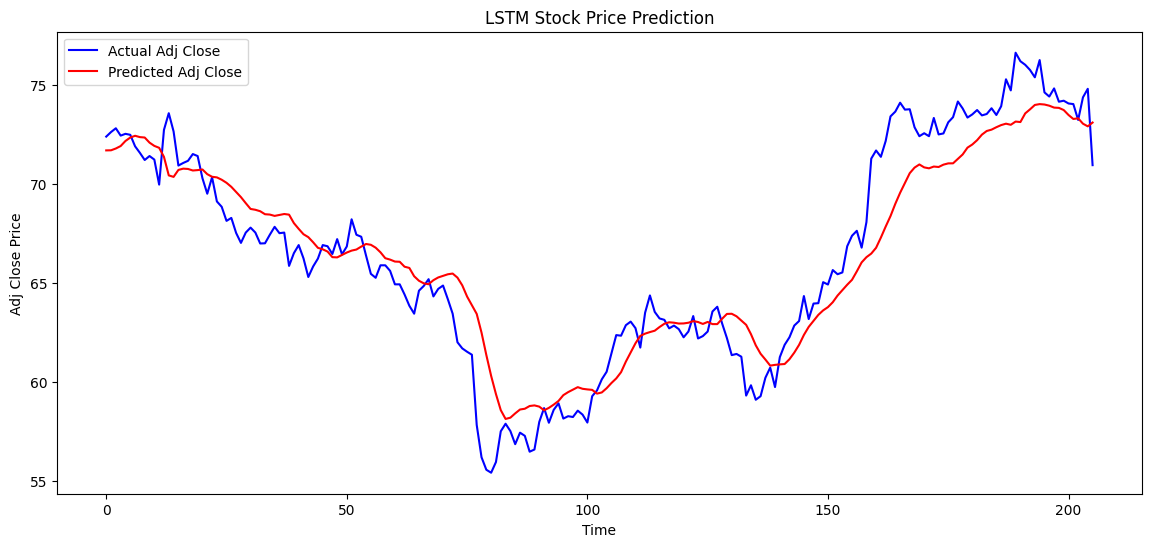

In [15]:
plt.figure(figsize=(14,6))  
# Create a large plot
plt.plot(actual_actual, color='blue', label='Actual Adj Close')  
# Plot real stock price values
plt.plot(predicted_actual, color='red', label='Predicted Adj Close')  
# Plot LSTM-predicted values
plt.title("LSTM Stock Price Prediction")  
# Plot title
plt.xlabel("Time")  
# X-axis label
plt.ylabel("Adj Close Price")  
# Y-axis label
plt.legend()  
# Show legend
plt.show()  
# Display the plot


# Evaluate Model

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
#Reasoning: import error metrics — MSE and MAE — and math for sqrt.
mse = mean_squared_error(actual_actual, predicted_actual)
#Reasoning: compute MSE, a common regression loss that measures average squared error magnitude; useful because it penalizes big errors strongly.
rmse = math.sqrt(mse)
#Reasoning: RMSE (root mean squared error) is on the same units as the target (e.g., price), making it easier to interpret.
mae = mean_absolute_error(actual_actual, predicted_actual)
#Reasoning: MAE measures average absolute error; it’s more robust to outliers than MSE and gives an intuitive average error magnitude.
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
#Reasoning: print numerical evaluation so you can quantitatively assess model accuracy and compare different models/hyperparameters.


MSE: 3.4457259664578426
RMSE: 1.8562666743918672
MAE: 1.4419885886815382
